# Group Project Team 009

## Introduction

provide some relevant background information on the topic so that someone unfamiliar with it will be prepared to understand the rest of your report
clearly state the question you tried to answer with your project
identify and fully describe the dataset that was used to answer the question


## Methods & Results

describe the methods you used to perform your analysis from beginning to end that narrates the analysis code.
your report should include code which:
loads data 
wrangles and cleans the data to the format necessary for the planned analysis
performs a summary of the data set that is relevant for exploratory data analysis related to the planned analysis 
creates a visualization of the dataset that is relevant for exploratory data analysis related to the planned analysis
performs the data analysis
creates a visualization of the analysis 
note: all figures should have a figure number(title) and a legend(readable)

In [20]:
library(tidyverse)
library(tidymodels)
library(repr)
library(kknn)
players <- read_csv("individual/players.csv")

clean_players <- players |> select(c(1,2,4,6,7))|> 
filter(!is.na(Age)) |> 
mutate(subscribe = as.factor(subscribe))|>  
mutate(gender = fct_collapse(
    gender,
    Male = c("Male"),
    Female = c("Female"),
    Other = c("Non-binary", "Other", "Two-Spirited", "Prefer not to say","Agender")))

head(clean_players)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `gender = fct_collapse(...)`.
Caused by warning:
! Unknown levels in `f`: Other”


experience,subscribe,played_hours,gender,Age
<chr>,<fct>,<dbl>,<fct>,<dbl>
Pro,TRUE,30.3,Male,9
Veteran,TRUE,3.8,Male,17
Veteran,FALSE,0.0,Male,17
Amateur,TRUE,0.7,Female,21
Regular,TRUE,0.1,Male,21
Amateur,TRUE,0.0,Female,17


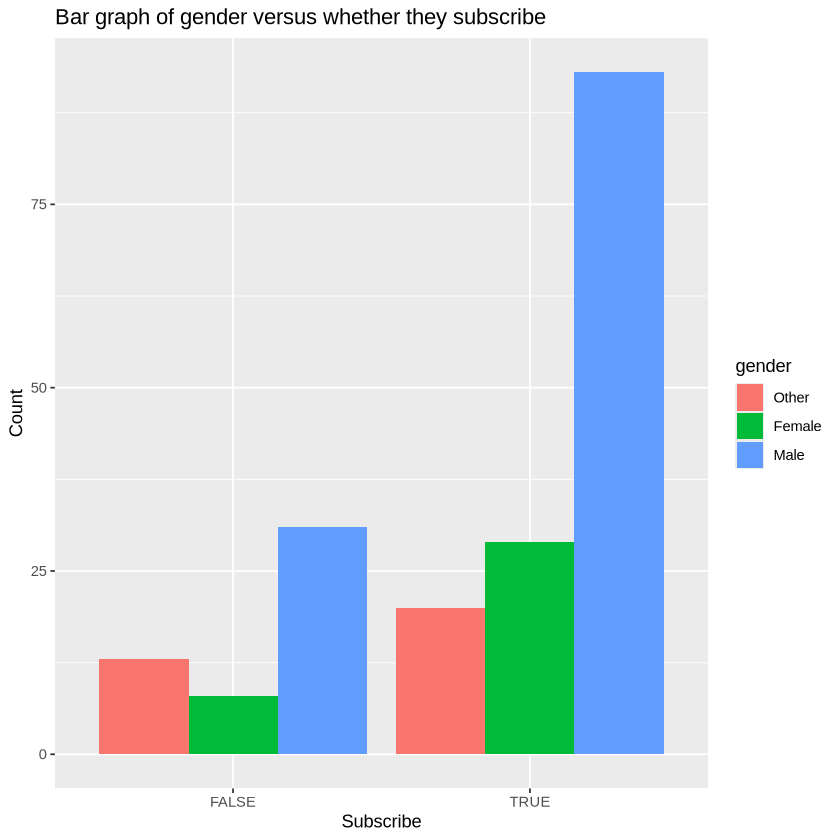

In [2]:
ggplot(clean_players, aes(x=subscribe)) + geom_bar(aes(fill=gender), position="dodge")+
xlab("Subscribe")+
ylab("Count")+
ggtitle("Bar graph of gender versus whether they subscribe")

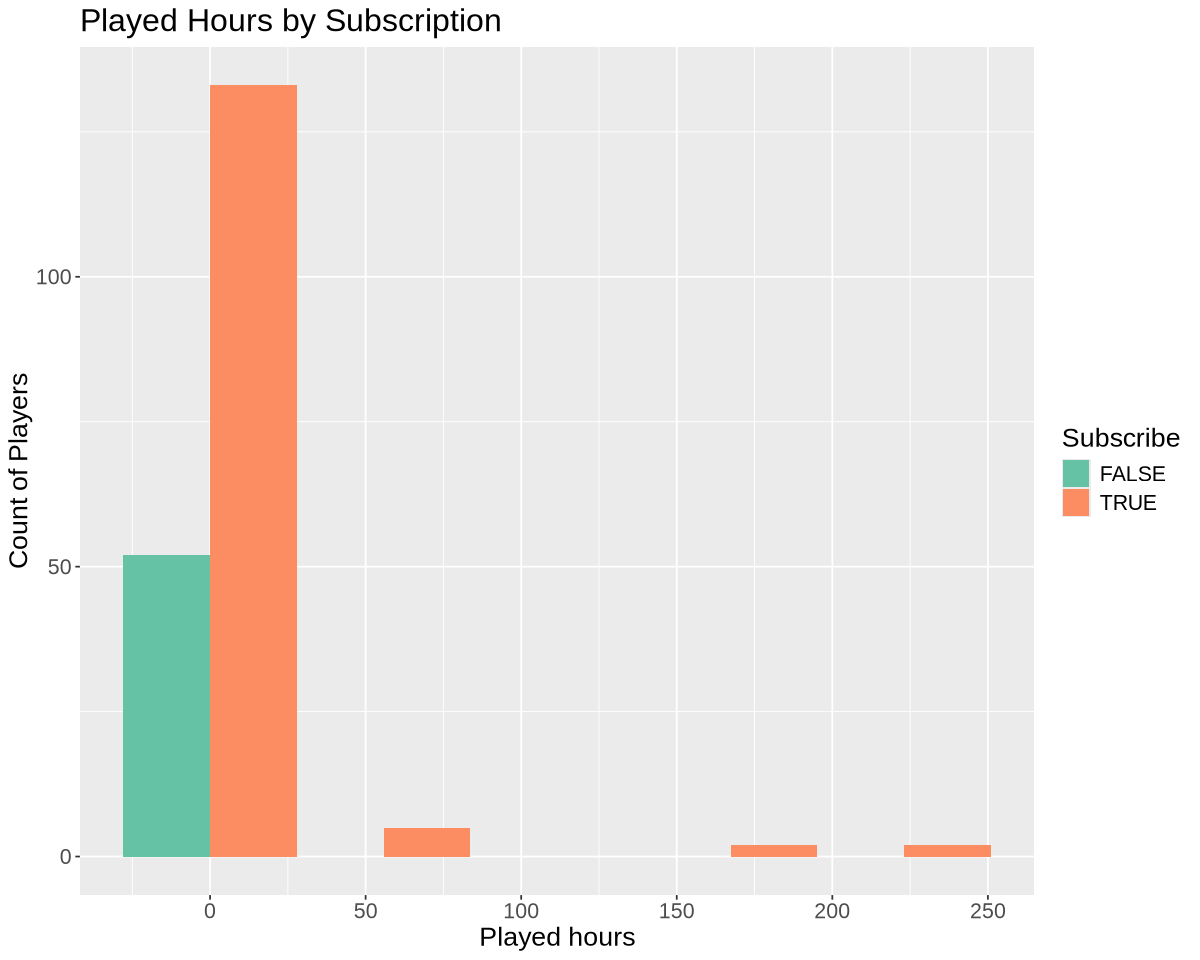

In [15]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = played_hours, fill = subscribe)) +
geom_histogram(position = "dodge", bins=5) +
labs(title = "Played Hours by Subscription",
       x = "Played hours", y = "Count of Players", fill = "Subscribe") +
theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Set2')

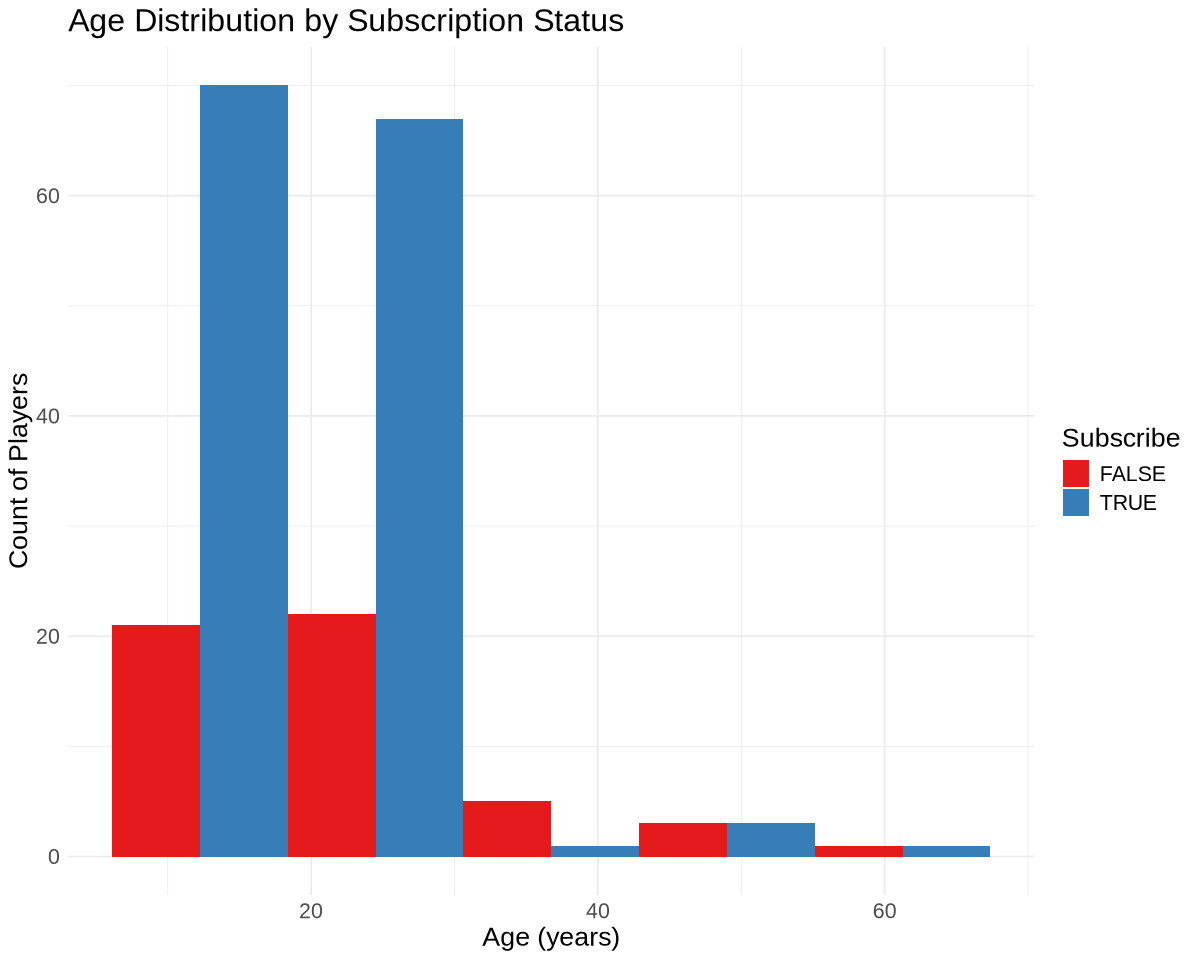

In [22]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = Age, fill = subscribe)) +
  geom_histogram(position = "dodge", bins = 5) +
  labs(title = "Age Distribution by Subscription Status",
       x = "Age (years)", y = "Count of Players", fill = "Subscribe") +
  theme_minimal() +theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Set1')

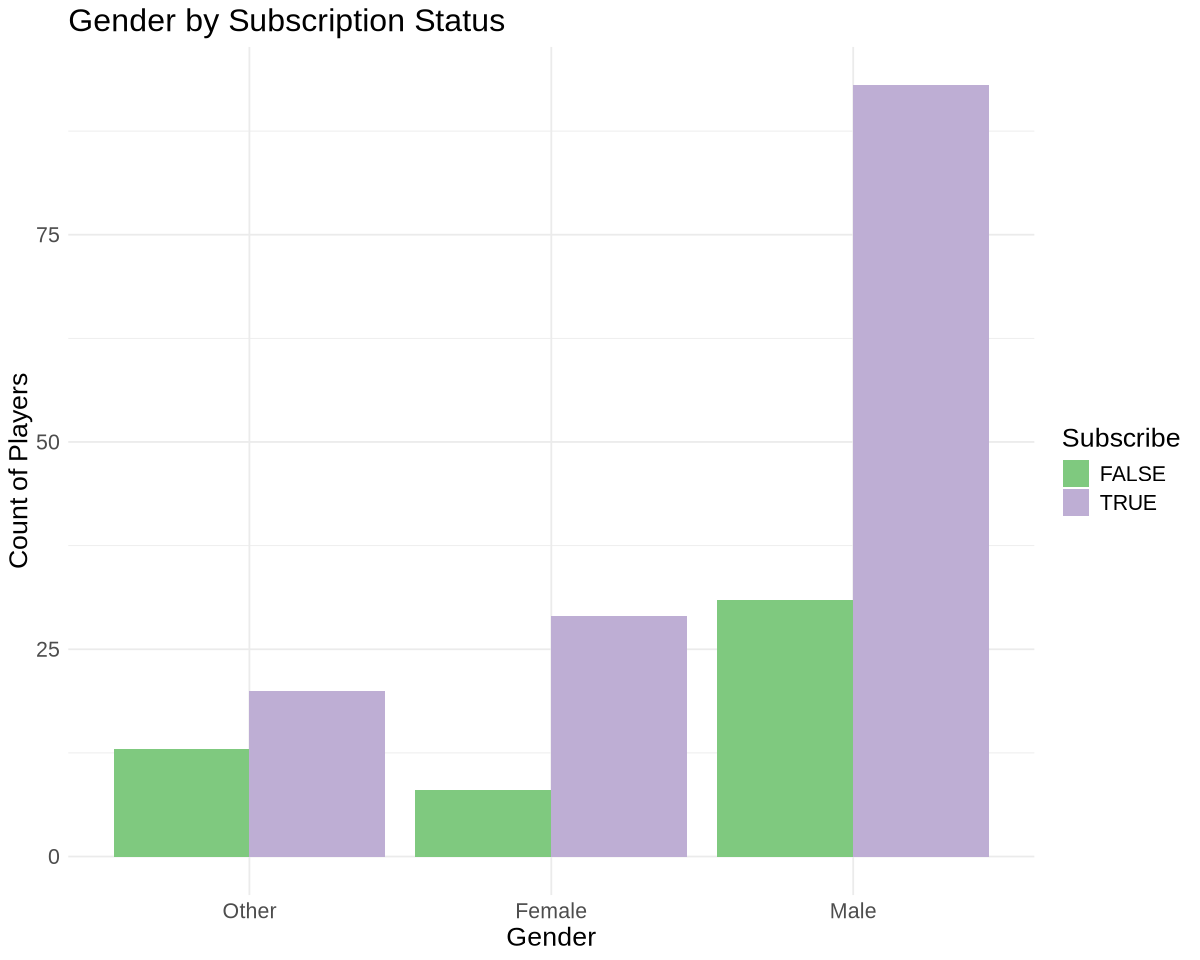

In [23]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = gender, fill = subscribe)) +
  geom_bar(position = "dodge") +
  labs(title = "Gender by Subscription Status",
       x = "Gender", y = "Count of Players", fill = "Subscribe") +
  theme_minimal() + theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Accent')

## Gender(one hot encoding)

In [4]:
clean_players_gender <- clean_players|> mutate(gender = as.factor(gender)) #one hot encoding requires it to be in factor form
gender_matrix <- model.matrix(~ gender-1, data = clean_players) # ~gender -1 means I change gender into numeric form
gender_players <- clean_players |>
  bind_cols(as_tibble(gender_matrix)) # change from matrix form to table form
gender_players

experience,subscribe,played_hours,gender,Age,genderOther,genderFemale,genderMale
<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Pro,TRUE,30.3,Male,9,0,0,1
Veteran,TRUE,3.8,Male,17,0,0,1
Veteran,FALSE,0.0,Male,17,0,0,1
Amateur,TRUE,0.7,Female,21,0,1,0
Regular,TRUE,0.1,Male,21,0,0,1
Amateur,TRUE,0.0,Female,17,0,1,0
Regular,TRUE,0.0,Female,19,0,1,0
Amateur,FALSE,0.0,Male,21,0,0,1
Amateur,TRUE,0.1,Male,47,0,0,1


In [5]:
set.seed(1123) # set. seed function makes sure you will obtain the exact same sequence of "random" numbers every time you run the code, the number inside is arbitary
# split
gender_split <- initial_split(gender_players, prop = 0.75, strata = subscribe)
gender_train <- training(gender_split)
gender_test <- testing(gender_split)

# recipe
gender_recipe <- recipe(subscribe ~ genderOther + genderFemale+ genderMale, data = gender_train) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

In [12]:
head(gender_train)

experience,subscribe,played_hours,gender,Age,genderOther,genderFemale,genderMale
<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Veteran,FALSE,0.0,Male,17,0,0,1
Amateur,FALSE,0.0,Male,22,0,0,1
Amateur,FALSE,0.1,Female,17,0,1,0
Veteran,FALSE,0.0,Male,23,0,0,1
Veteran,FALSE,0.1,Male,18,0,0,1
Amateur,FALSE,0.0,Other,33,1,0,0


In [7]:

# specification
gender_spec_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

# k-values
gender_ks <- tibble(neighbors = 1:20)

# v-fold
gender_vfold <- vfold_cv(gender_train, v = 5, strata = subscribe)

In [8]:
# workflow with validation
gender_fit <- workflow() |>
  add_recipe(gender_recipe) |>
  add_model(gender_spec_tune) |>
  tune_grid(resamples = gender_vfold, grid = gender_ks) 

# accuracy
gender_tune_accuracy <- gender_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)

gender_tune_accuracy
# rm(list = ls())

neighbors,mean
<int>,<dbl>
17,0.4203777
18,0.4203777
19,0.3996880
20,0.3996880
13,0.3789984
14,0.3789984
15,0.3789984
16,0.3789984
11,0.3589984


In [9]:
gender_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 17) |>
  set_engine("kknn") |>
  set_mode("classification")

gender_recipe <- recipe(subscribe ~ genderOther + genderFemale+ genderMale, data = gender_train) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())



In [10]:
# workflow with validation
gender_fit <- workflow() |>
  add_recipe(gender_recipe) |>
  add_model(gender_spec) |>
  fit(data = gender_train)



In [11]:
predictions <- predict(gender_fit, gender_test) |>
  bind_cols(gender_test)
predictions
#cancer_test_predictions |>
 # metrics(truth = Class, estimate = .pred_class) |>
#  filter(.metric == "accuracy")

.pred_class,experience,subscribe,played_hours,gender,Age,genderOther,genderFemale,genderMale
<fct>,<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
FALSE,Veteran,TRUE,3.8,Male,17,0,0,1
FALSE,Regular,TRUE,0.1,Male,21,0,0,1
FALSE,Amateur,FALSE,0.0,Male,21,0,0,1
FALSE,Amateur,TRUE,0.1,Male,47,0,0,1
FALSE,Veteran,TRUE,0.0,Other,17,1,0,0
TRUE,Amateur,TRUE,48.4,Female,17,0,1,0
FALSE,Amateur,TRUE,0.5,Male,17,0,0,1
TRUE,Amateur,TRUE,0.7,Female,21,0,1,0
FALSE,Amateur,TRUE,0.3,Male,24,0,0,1


## Age (ordinary encoding)

## played hour (ordinary encoding)

## Discussion

summarize what you found(accuracy)
discuss whether this is what you expected to find
discuss what impact could such findings have
discuss what future questions could this lead to

## Reference 